In [7]:
import pandas as pd
import keras
import sklearn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import tensorflow as tf
import math

In [4]:
def plot_image_grid(images, labels, predictions, n_preds=20, cols=5):
    # Obliczamy ile rzędów potrzebujemy (np. dla 20 obrazków i 5 kolumn = 4 rzędy)
    rows = math.ceil(n_preds / cols)
    
    # Tworzymy większe okno, żeby wszystko się pomieściło
    plt.figure(figsize=(cols * 3, rows * 4)) 
    
    for i in range(n_preds):
        plt.subplot(rows, cols, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i])
        
        true_label = classes[labels[i]]
        pred_label = classes[predictions[i]]
        
        # Pro tip: kolorujemy napisy! 
        # Zielony = trafiony, Czerwony = pudło
        color = 'green' if true_label == pred_label else 'red'
        
        # Wyświetlamy informację nad obrazkiem
        plt.title(f"Prawda: {true_label}\nPred: {pred_label}", 
                  color=color, fontsize=10)
        
    # Ten magiczny przycisk naprawia nakładanie się elementów
    plt.tight_layout()
    plt.show()

# Wczytanie danych

In [5]:
def load_waste_dataframe(base_path, split_name):
    """
    base_path: ścieżka do głównego folderu (np. 'dataset/')
    split_name: nazwa podfolderu ze zbiorem (np. 'train', 'valid' lub 'test')
    """
    search_path = os.path.join(base_path, split_name)
    
    filepaths = glob.glob(os.path.join(search_path, "**", "*.jpg"), recursive=True)
    
    labels = [os.path.basename(os.path.dirname(fp)) for fp in filepaths]
    
    df = pd.DataFrame({
        'filepath': filepaths,
        'label': labels,
        'split': split_name
    })
    
    return df

In [8]:
train_df = load_waste_dataframe("dataset/", "train")
valid_df = load_waste_dataframe("dataset/", "valid")
test_df = load_waste_dataframe("dataset/", "test")

In [9]:
waste_data = pd.concat([train_df, valid_df, test_df], ignore_index=True)

In [10]:
waste_data.head()

,filepath,label,split
0,dataset/train\cardboard\cardboard100_jpg.rf.ae...,cardboard,train
1,dataset/train\cardboard\cardboard101_jpg.rf.ec...,cardboard,train
2,dataset/train\cardboard\cardboard103_jpg.rf.3a...,cardboard,train
3,dataset/train\cardboard\cardboard104_jpg.rf.43...,cardboard,train
4,dataset/train\cardboard\cardboard105_jpg.rf.98...,cardboard,train


In [11]:
waste_data['label'].value_counts()

label
paper        594
glass        501
plastic      480
metal        409
cardboard    403
trash        137
Name: count, dtype: int64

In [12]:
waste_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filepath  2524 non-null   str  
 1   label     2524 non-null   str  
 2   split     2524 non-null   str  
dtypes: str(3)
memory usage: 59.3 KB


# Preprocessing

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
encoder = LabelEncoder()

waste_data['label'] = encoder.fit_transform(waste_data['label'])

amount_of_classes = len(encoder.classes_)
display(waste_data.head())

,filepath,label,split
0,dataset/train\cardboard\cardboard100_jpg.rf.ae...,0,train
1,dataset/train\cardboard\cardboard101_jpg.rf.ec...,0,train
2,dataset/train\cardboard\cardboard103_jpg.rf.3a...,0,train
3,dataset/train\cardboard\cardboard104_jpg.rf.43...,0,train
4,dataset/train\cardboard\cardboard105_jpg.rf.98...,0,train


In [15]:
classes = encoder.classes_ 
print(classes)

['cardboard' 'glass' 'metal' 'paper' 'plastic' 'trash']


In [16]:
img_size = (128, 128)
X_list = []

for path in waste_data['filepath']:
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    X_list.append(img)

X = np.array(X_list) / 255.0
y = np.array(waste_data['label'])

# Podział na zbiory

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [19]:
print(len(X_train))
print(len(X_valid))
print(len(X_test))

1766
379
379


# Sieć Neuronowa

In [20]:
from functools import partial

default_conv = partial(
    tf.keras.layers.Conv2D,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
)

In [39]:
# model = keras.Sequential([
#     tf.keras.Input(shape=(128, 128, 3)),
#     default_conv(16),
#     default_conv(16),
#     tf.keras.layers.MaxPooling2D(),
#     default_conv(32),
#     default_conv(32),
#     tf.keras.layers.MaxPooling2D(),
#     default_conv(64),
#     default_conv(64),
#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(64, activation="relu"),
#     tf.keras.layers.Dense(amount_of_classes, activation="softmax")
# ])

In [ ]:
from keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

model = keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    data_augmentation,
    
    default_conv(32),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    default_conv(64),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    default_conv(128),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    default_conv(256),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(amount_of_classes, activation="softmax")
])

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    lr_scheduler
]

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer='adamw',
    metrics=['accuracy']
)



In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [42]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid), callbacks=callbacks)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 732ms/step - accuracy: 0.3974 - loss: 1.5503 - val_accuracy: 0.1979 - val_loss: 1.8161 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 38s 687ms/step - accuracy: 0.5531 - loss: 1.2189 - val_accuracy: 0.1979 - val_loss: 1.8825 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 613ms/step - accuracy: 0.5580 - loss: 1.1652 - val_accuracy: 0.1953 - val_loss: 2.0471 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 592ms/step - accuracy: 0.5641 - loss: 1.1615 - val_accuracy: 0.2348 - val_loss: 2.3227 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 569ms/step - accuracy: 0.6183 - loss: 1.0493 - val_accuracy: 0.2797 - val_loss: 1.7524 - learning_rate: 2.0000e-04
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 36s 642ms/step - accuracy: 0.6545 - loss: 0.9586 - val_accuracy: 0.3087 - val_loss: 1.7976 - learning_rate: 2.0000e-04
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 582ms/step - accuracy: 0.6876 - 

# Wczytywanie i zapisywanie modelu

Ponieważ uczenie modelu trwa ~20 min można wczytać juz zapisany przeze mnie model.

In [43]:
model.save_weights('model_weights.weights.h5')

In [23]:
model.load_weights('model_weights.weights.h5')

c:\Studia\NikTech\venv\Lib\site-packages\keras\src\saving\saving_lib.py:415: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Wczytywanie modelu .keras zwraca błąd ze względu na konflikty w kerasie

In [45]:
# model.save('test_model_1.keras')

In [46]:
# model = keras.models.load_model('test_model_1.keras')

# Historia

In [24]:
def display_history(history):
    sns.lineplot(history.history)
    plt.grid()
    plt.xlabel("Epoch")

display_history(history)

NameError: name 'history' is not defined

# Predykcje

In [31]:
# test_preds = model.predict(X_test)
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step


In [32]:
display(y_pred[:10])

array([2, 4, 0, 1, 1, 1, 3, 3, 3, 3], dtype=int64)

In [34]:
y_test[:10]

array([2, 4, 0, 1, 1, 4, 3, 4, 3, 3])

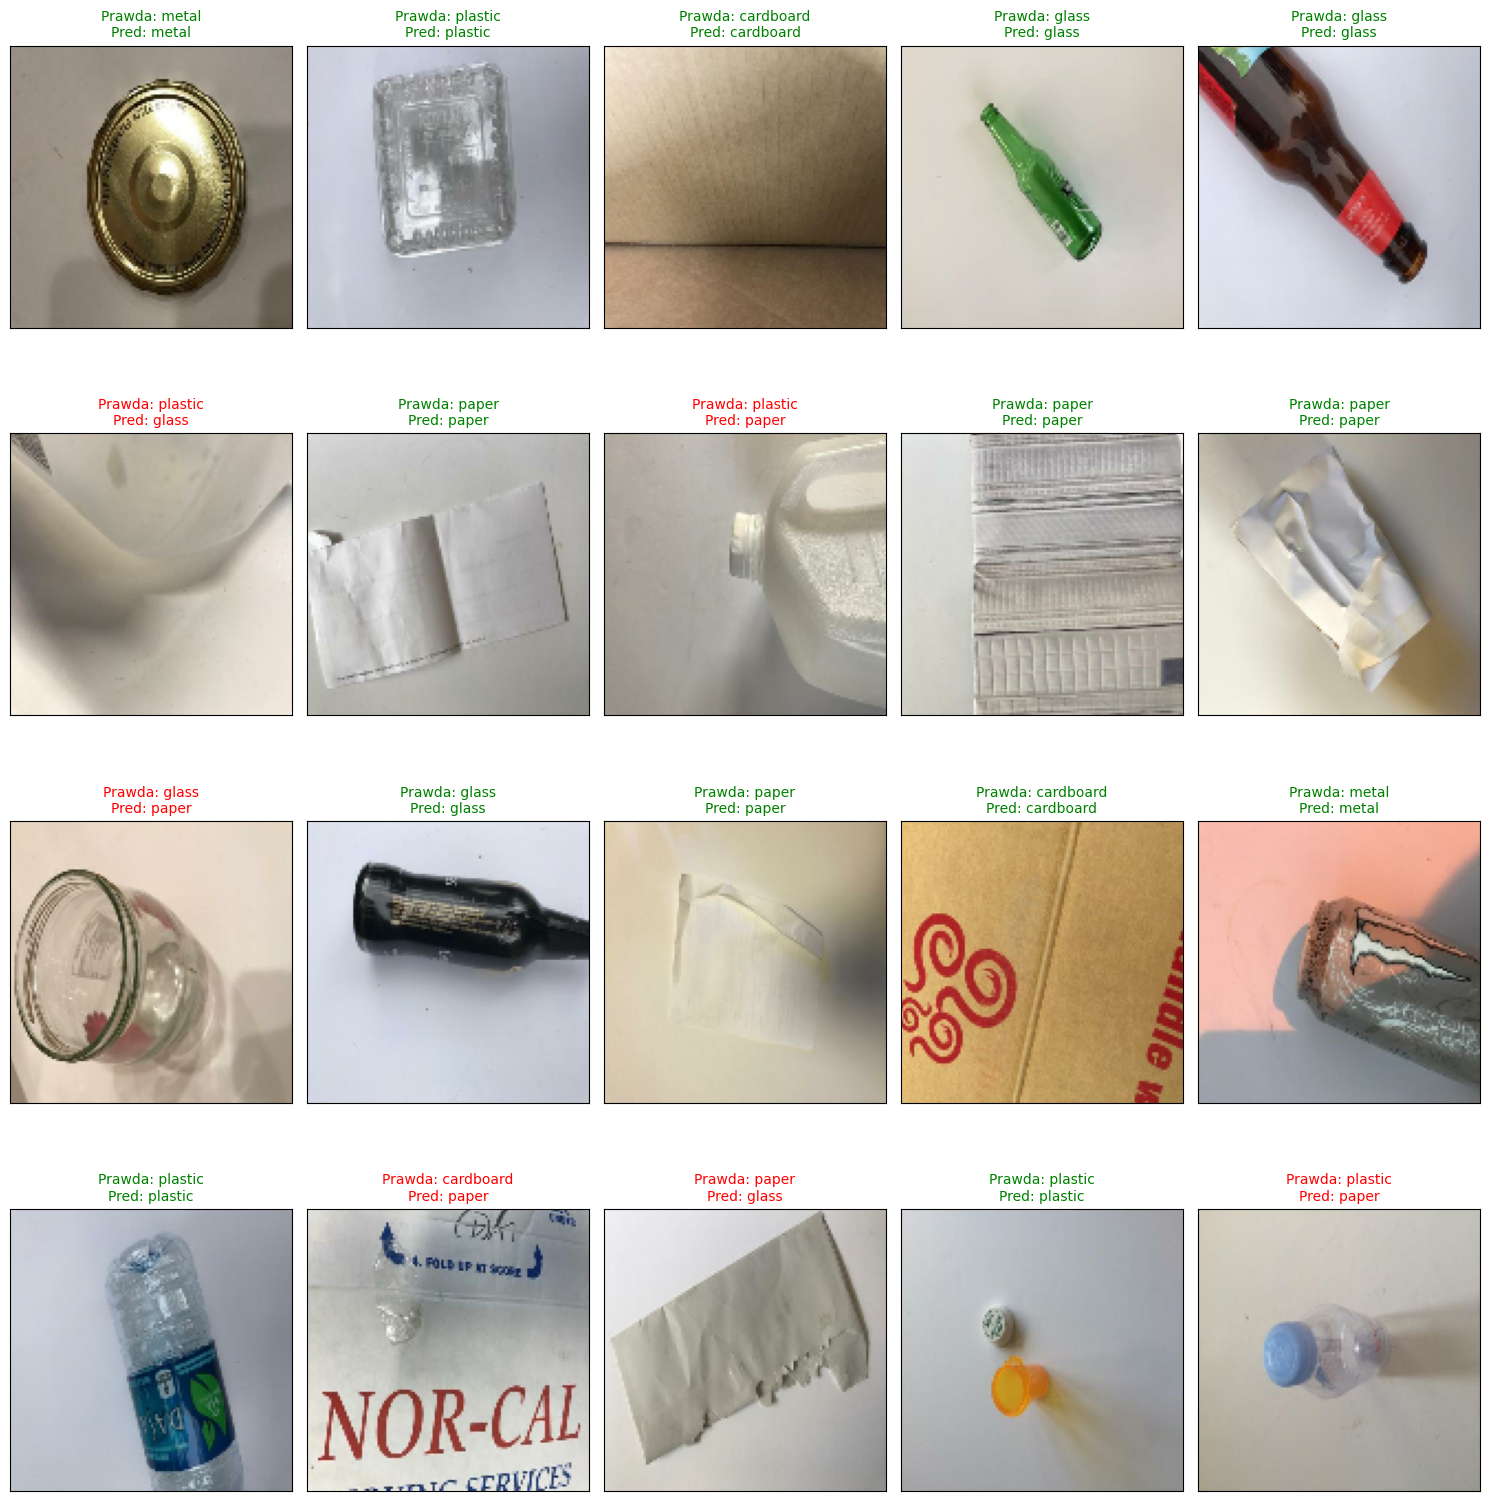

In [35]:
plot_image_grid(X_test[:20], y_test[:20], y_pred, n_preds=20)

# Miary jakości modelu

In [1]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

In [ ]:
print("Test acc:", accuracy_score(y_test, y_pred))

Test acc: 0.7282321899736148


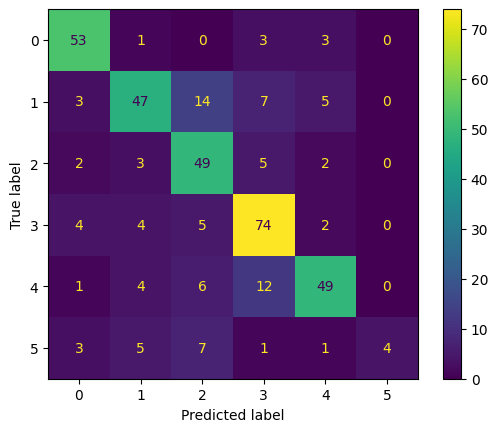

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [40]:
print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

   cardboard       0.80      0.88      0.84        60
       glass       0.73      0.62      0.67        76
       metal       0.60      0.80      0.69        61
       paper       0.73      0.83      0.77        89
     plastic       0.79      0.68      0.73        72
       trash       1.00      0.19      0.32        21

    accuracy                           0.73       379
   macro avg       0.78      0.67      0.67       379
weighted avg       0.75      0.73      0.72       379

